In [1]:
!nvidia-smi

Thu Jul 16 13:45:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          On  |   00000000:87:00.0 Off |                    0 |
| N/A   18C    P0             67W /  700W |       1MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib widget
%pwd

'/ocean/projects/asc170022p/mtragoza/lung-project/notebooks/copdgene'

In [3]:
import sys, os
sys.path.append(os.environ['LP'])
import project
from project.core.utils import pprint

In [4]:
data_root = '/ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene'
#data_root = '/restricted/projectnb/batmanlab/mragoza/COPDGene'

In [5]:
import project.datasets.copdgene
dataset_cls = project.datasets.copdgene.COPDGeneDataset
ds = dataset_cls(data_root)
ds

project.datasets.copdgene.COPDGeneDataset('/ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene')

# Visualize source images

In [6]:
examples = ds.list_examples(
    subjects='../../data/COPDGene/sample1000_2025-05-21.csv',
    state_pairs=[('EXP', 'INSP')]
)
len(examples)

1000

In [7]:
ex = examples[0]
pprint(ex, 4, 20)

Example()
├── dataset:  'COPDGene'
├── subject:  '16514P'
├── variant:  None
├── paths:    dict(len=3)
|   ├── 'ref_state':  dict(len=2)
|   |   ├── 'source_image': PosixPath('/ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Images/16514P/Phase-1/RAW/16514P_INSP_STD_TEM_COPD.nii.gz')
|   |   └── 'source_json':  PosixPath('/ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Images/16514P/Phase-1/RAW/16514P_INSP_STD_TEM_COPD.json')
|   ├── 'init_state': dict(len=2)
|   |   ├── 'source_image': PosixPath('/ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Images/16514P/Phase-1/RAW/16514P_EXP_STD_TEM_COPD.nii.gz')
|   |   └── 'source_json':  PosixPath('/ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Images/16514P/Phase-1/RAW/16514P_EXP_STD_TEM_COPD.json')
|   └── 'curr_state': dict(len=2)
|       ├── 'source_image': PosixPath('/ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Images/16514P/Phase-1/RAW/16514P_INSP_STD_TEM_COPD.

In [8]:
import numpy as np
import nibabel as nib

img0 = project.core.fileio.load_nibabel(ex.paths['init_state']['source_image'])
img1 = project.core.fileio.load_nibabel(ex.paths['curr_state']['source_image'])

spacing0 = tuple(float(d) for d in img0.affine[:3,:3] @ np.ones(3))
print(spacing0)

spacing1 = tuple(float(d) for d in img1.affine[:3,:3] @ np.ones(3))
print(spacing1)

img0.affine

Loading /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Images/16514P/Phase-1/RAW/16514P_EXP_STD_TEM_COPD.nii.gz
Loading /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Images/16514P/Phase-1/RAW/16514P_INSP_STD_TEM_COPD.nii.gz
(-0.71875, 0.71875, 0.5)
(-0.71875, 0.71875, 0.7000007629394531)


array([[  -0.71875 ,   -0.      ,    0.      ,  167.640625],
       [   0.      ,    0.71875 ,    0.      ,   -6.640625],
       [   0.      ,    0.      ,    0.5     , -319.      ],
       [   0.      ,    0.      ,    0.      ,    1.      ]])

In [9]:
import project.visual.matplotlib as mpl_viz

img_kws = dict(cmap='gray', vmin=-1000, vmax=-250)

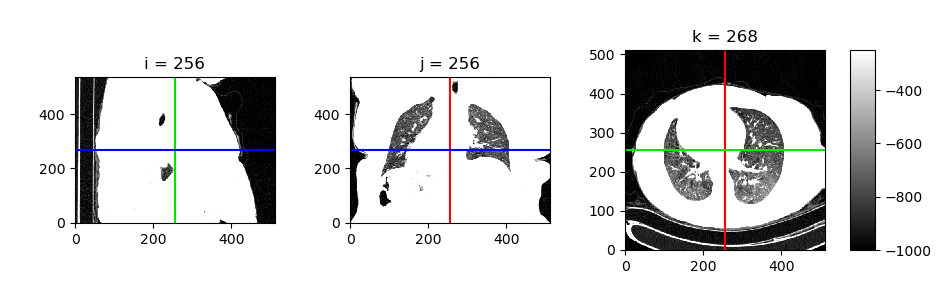

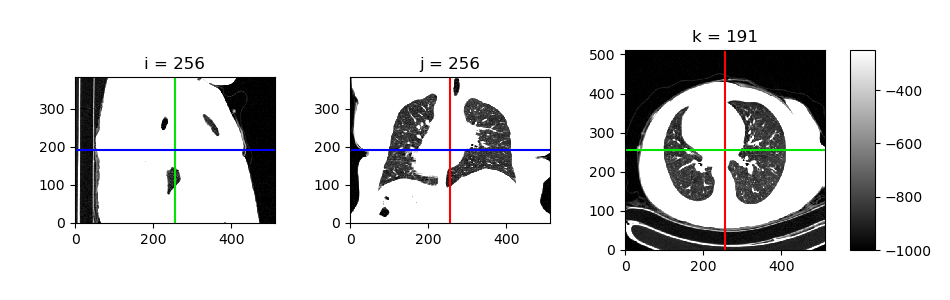

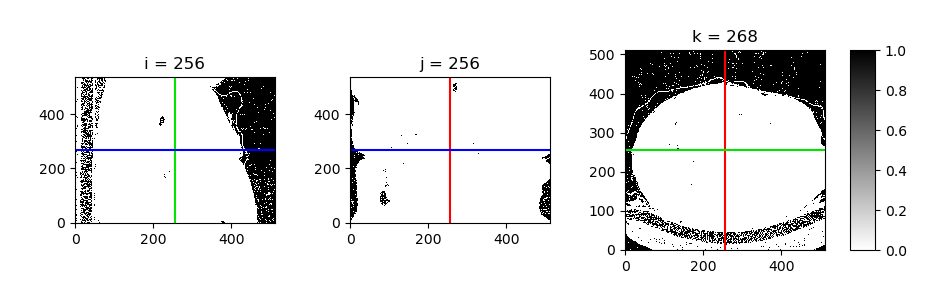

In [10]:
mpl_viz.SliceViewer(img0.get_fdata(), vox_spacing=spacing0, **img_kws)
mpl_viz.SliceViewer(img1.get_fdata(), vox_spacing=spacing1, **img_kws)

emph = (img0.get_fdata() <= -950)
mpl_viz.SliceViewer(emph, vox_spacing=spacing0, cmap='binary', vmin=0, vmax=1)

# Preprocessing tests

In [11]:
proc_config = {
    'image_resampling': {
        'spacing': (1.0, 1.0, 1.0),
        'interpolation': 'linear',
        'default_value': -1024.
    },
    'image_segmentation': {
        'tasks': [
            {
                'task_name': 'total',
                'roi_subset': [
                    'lung_upper_lobe_right',
                    'lung_middle_lobe_right',
                    'lung_lower_lobe_right',
                    'lung_upper_lobe_left',
                    'lung_lower_lobe_left',
                ],
            },
        ],
        'combine': True
    },
    'image_registration': {
        'method': 'unigradicon',
        'args': {
            'model': 'gradiconlung',
            'io_sim': 'lncc2',
            'io_iterations': 50,
            'io_sigma': 1,
            'loss_function_masking': True,
            'intensity_conservation': True
        }
    },
    'region_labeling': {
        'roi_order': [
            'lung_upper_lobe_right',
            'lung_middle_lobe_right',
            'lung_lower_lobe_right',
            'lung_upper_lobe_left',
            'lung_lower_lobe_left',
        ],
        'region_filter': {
            'min_voxels': 30,
            'keep_largest': True
        }
    },
    'mesh_generation': {
        'use_affine_spacing': True,
        'mesh_parameters': {
            'max_facet_distance': 0.75,
            'max_cell_circumradius': 5.0,
            'lloyd': True,
            'odt': True
        }
    },
    'mesh_interpolation': {}
}

In [12]:
examples = ds.list_examples(
    subjects='../../data/COPDGene/sample1000_2025-05-21.csv',
    state_pairs=[('EXP', 'INSP')],
    variant='TEST',
    pipeline_tags={
        'image_segmentation': 'tseg',
        'image_registration': 'lung'
    }
)

In [13]:
%autoreload
import project.preprocessing.api as api

bin_path = '/ocean/projects/asc170022p/mtragoza/mambaforge/envs/warp/bin'
os.environ['PATH'] = bin_path + ':' + os.environ['PATH']

for ex in examples[:1]:
    api.preprocess_example(ex, proc_config)

print('Done')

INFO: /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Processed/TEST/16514P/images/16514P_EXP_std.nii.gz exists; Skipping stage resample_image_spacing
INFO: /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Processed/TEST/16514P/images/16514P_INSP_std.nii.gz exists; Skipping stage resample_image_spacing
INFO: /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_tseg_combined.nii.gz exists; Skipping stage create_segmentation_masks
INFO: /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_tseg_regions.nii.gz exists; Skipping stage map_regions_from_masks
INFO: /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Processed/TEST/16514P/masks/16514P_INSP_std_tseg_combined.nii.gz exists; Skipping stage create_segmentation_masks
INFO: /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Processed/TEST/16514P/masks/16514P_INSP_std_tseg_region

In [29]:
import numpy as np

img0 = project.core.fileio.load_nibabel(ex.paths['init_state']['resampled_image'])
img1 = project.core.fileio.load_nibabel(ex.paths['curr_state']['resampled_image'])
mask = project.core.fileio.load_nibabel(ex.paths['region_map']).get_fdata()

spacing0 = tuple(float(d) for d in img0.affine[:3,:3] @ np.ones(3))
print(spacing0)

spacing1 = tuple(float(d) for d in img1.affine[:3,:3] @ np.ones(3))
print(spacing1)

img0.affine

Loading /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Processed/TEST/16514P/images/16514P_EXP_std.nii.gz
Loading /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Processed/TEST/16514P/images/16514P_INSP_std.nii.gz
Loading /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_tseg_regions.nii.gz
(-1.0, 1.0, 1.0)
(-1.0, 1.0, 1.0)


array([[  -1.       ,   -0.       ,    0.       ,  167.5      ],
       [  -0.       ,    1.       ,   -0.       ,   -6.5      ],
       [   0.       ,    0.       ,    1.       , -318.3001709],
       [   0.       ,    0.       ,    0.       ,    1.       ]])

In [15]:
img_kws = dict(cmap='gray', vmin=-1024, vmax=-256)

cmap = mpl_viz.get_label_cmap(n_labels=10, select=None, include_bg=True)
mask_kws = dict(cmap=cmap, vmin=0, vmax=10)

disp_kws = dict(cmap='seismic', vmin=-20, vmax=20)

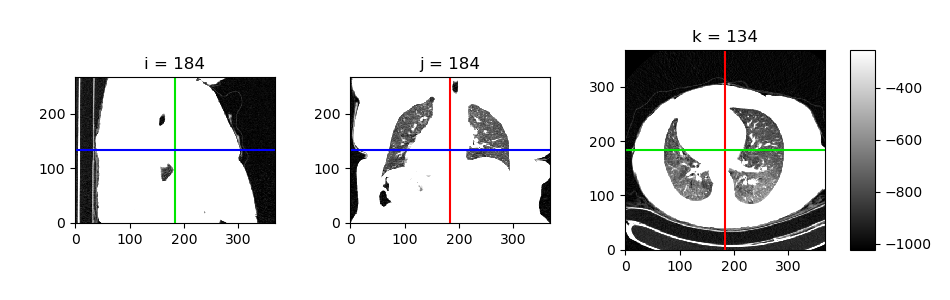

In [30]:
mpl_viz.SliceViewer(img0.get_fdata(), vox_spacing=spacing0, **img_kws)
#mpl_viz.SliceViewer(img1.get_fdata(), vox_spacing=spacing1, **img_kws)
#mpl_viz.SliceViewer(mask, vox_spacing=spacing0, **mask_kws)

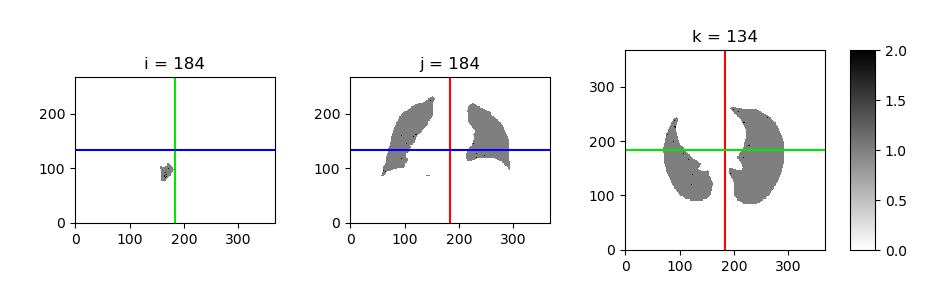

In [17]:
m = mask > 0
emph = img0.get_fdata() < -900

mpl_viz.SliceViewer((emph + 1) * m, vox_spacing=spacing0, cmap='binary', clim=(0,2))

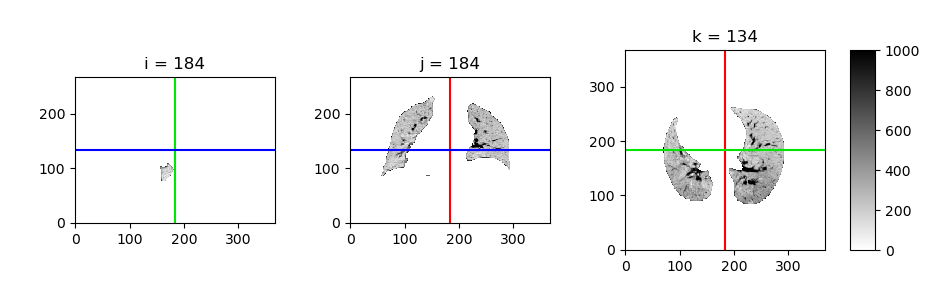

In [18]:
m = mask > 0
rho = img0.get_fdata() + 1000

mpl_viz.SliceViewer(rho * m, vox_spacing=spacing0, cmap='binary', clim=(0,1000))

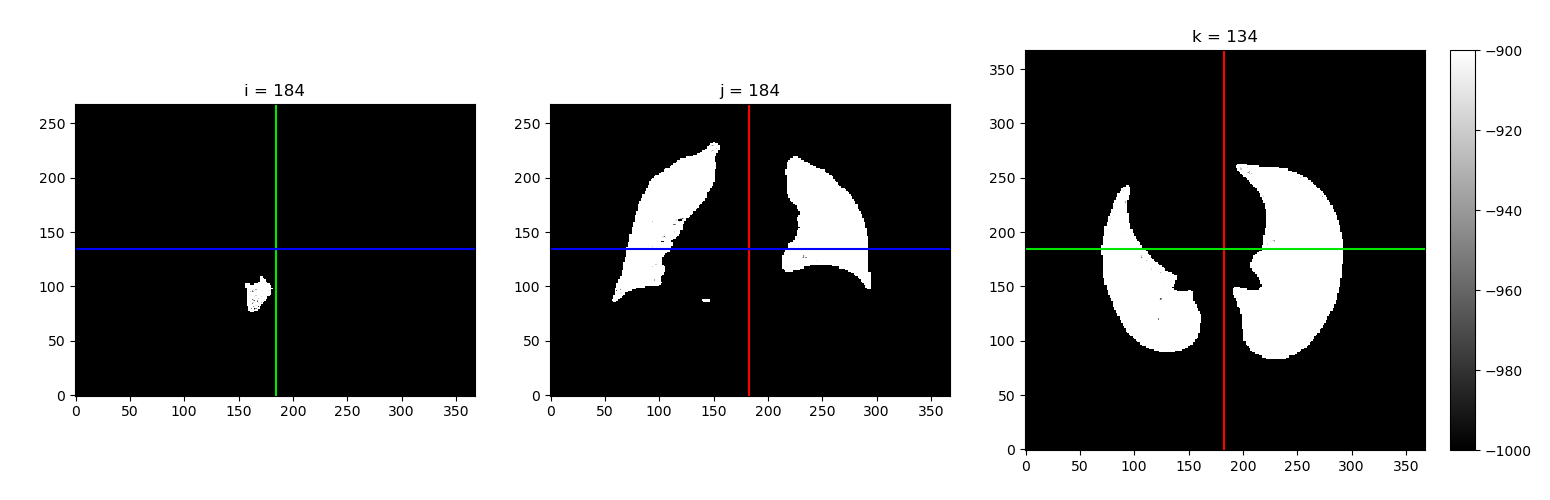

In [28]:
mpl_viz.SliceViewer(img0.get_fdata() * m + (-1000) * (1 - m), vox_spacing=spacing0, cmap='gray', vmin=-1000, vmax=-900, ax_width=4, ax_height=4)

Loading /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Processed/TEST/16514P/fields/16514P_EXP_std_tseg_lung_INSP.nii.gz


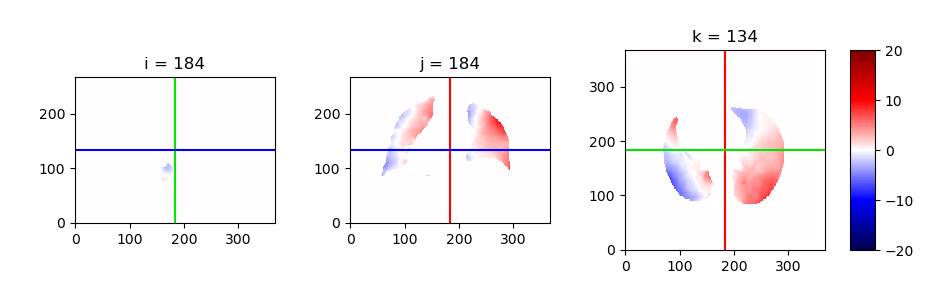

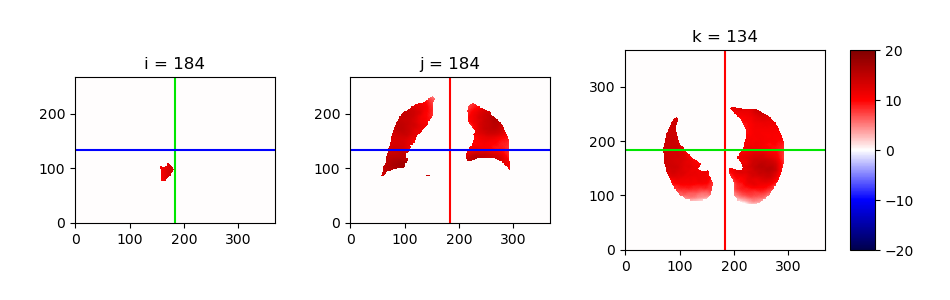

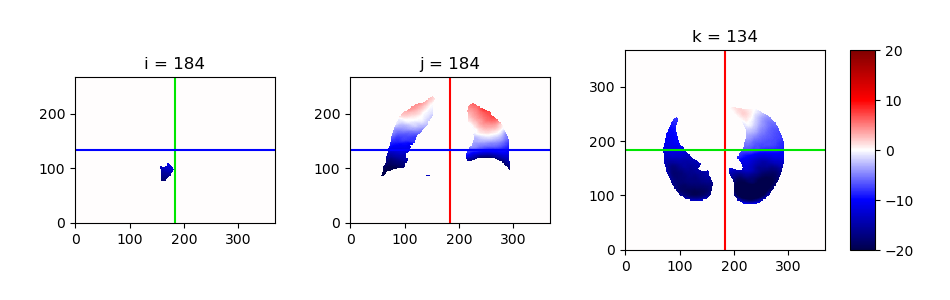

In [19]:
disp_path = str(ex.paths['disp_field'])
disp = project.core.fileio.load_nibabel(disp_path).get_fdata()

mpl_viz.SliceViewer(disp[...,0] * (mask > 0), vox_spacing=spacing0, **disp_kws)
mpl_viz.SliceViewer(disp[...,1] * (mask > 0), vox_spacing=spacing0, **disp_kws)
mpl_viz.SliceViewer(disp[...,2] * (mask > 0), vox_spacing=spacing0, **disp_kws)

In [20]:
mesh = project.core.fileio.load_meshio(ex.paths['interp_mesh'])
mesh

Loading /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Processed/TEST/16514P/meshes/16514P_EXP_std_tseg_regions_pyg_lung_INSP_int.xdmf


<meshio mesh object>
  Number of points: 23583
  Number of cells:
    tetra: 99939
  Point data: medit:ref, image, u_true
  Cell data: medit:ref, region, image, u_true

In [30]:
import project.visual.pyvista as pv_viz

In [31]:
np.arange(0, 1000, 4).shape

(250,)

2026-06-23 11:04:53.536 (1742.407s) [    1469790C6400]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=


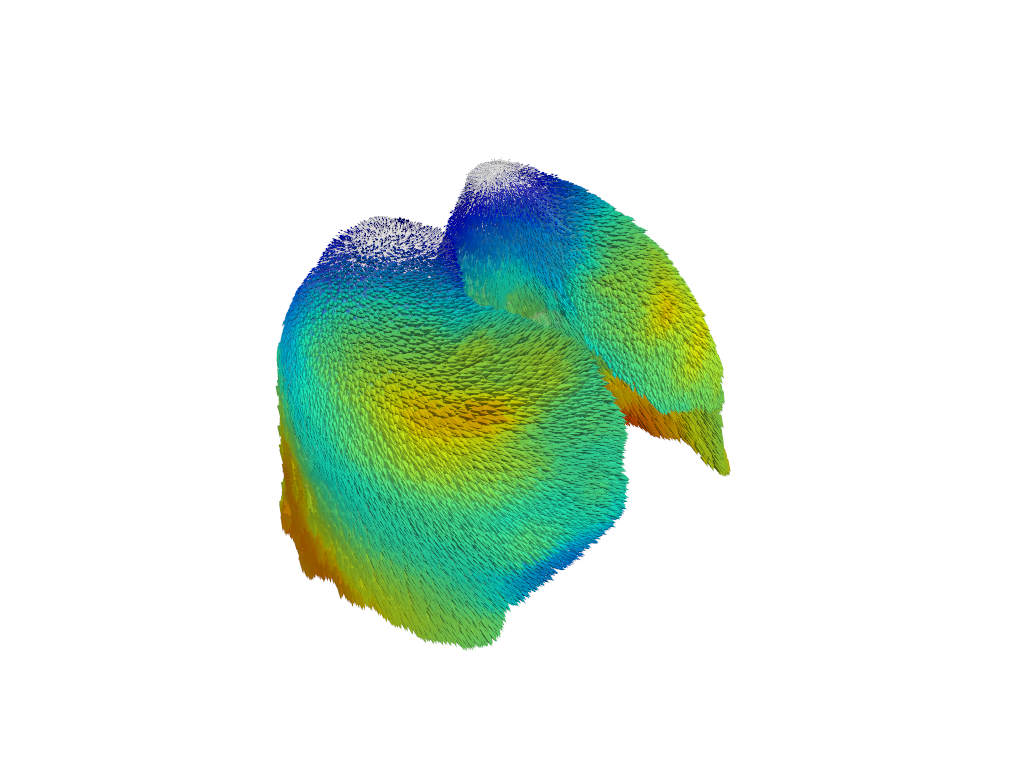

In [32]:
def show_mesh(mesh, key):
    import pyvista as pv
    m = pv.wrap(mesh)
    p = pv.Plotter()
    p.add_mesh(m, show_scalar_bar=False, color='white', opacity=0.2)
    g = m.glyph(scale=key, orient=key, factor=1.0)
    p.add_mesh(g, show_scalar_bar=False, cmap='jet')
    p.show(jupyter_backend='static')

show_mesh(mesh, key='u_true')

# Optimization

In [25]:
import math

opt_config = {
    'targets': ['G', 'K'],
    'param_specs': {
        'G': {'mode': 'log10', 'mean': 3.0, 'std': 0.1},
        'K': {'mode': 'log10', 'mean': 3.7, 'std': 0.1},
        'rho': {'mode': 'log10', 'mean': 2.4, 'std': 0.1}
    },
    'physics_adapter': {
        'default_nu': 0.4,
        'default_rho': 250
    },
    'pde_solver': {
        '_class': 'WarpFEMSolver',
        'material_type': 'neohookean',
        'relative_loss': True,
        'tv_reg_weight': 1e-4, #0.001,
        'newton_steps': 100,
        'newton_alpha': 1.0,
        'newton_beta': 0.5, #math.sqrt(0.5),
        'newton_rtol': 1e-5,
        'cg_maxiter': 0, #100,
        'cg_rtol': 1e-5, #1e-4,
        'verbose': False
    },
    'optimizer': {
        '_class': 'Adam',
        'lr': 0.1,
        'global_steps': 10,
        'local_steps': 100,
        'tol': 1e-3
    },
    'initialize': {
        'num_restarts': 1,
        'noise_std': 0.1
    },
    'boundary_condition': {
        'name': 'u_true'
    }
}

In [26]:
%autoreload
import project.optimization
project.optimization.simulate_example(ex, opt_config)

Loading /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Processed/TEST/16514P/images/16514P_EXP_std.nii.gz
Loading /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Processed/TEST/16514P/meshes/16514P_EXP_std_tseg_regions_pyg_lung_INSP_int.xdmf
Loading /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_tseg_regions.nii.gz
Targets: ['G', 'K']
Warp 1.10.0.dev20251007 initialized:
   Git commit: 5ddc94f042dc7a41d22911dcff7800ab6da3be29
   CUDA Toolkit 12.8, Driver 12.6
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "Tesla V100-SXM2-32GB" (32 GiB, sm_70, mempool enabled)
   Kernel cache:
     /jet/home/mtragoza/.cache/warp/1.10.0.dev20251007


RuntimeError: Line search failed at Newton step 2

In [82]:
outputs = {}
outputs['linear'] = project.core.paths.RunOutputs(stage='opt_linear')
outputs['stvk'] = project.core.paths.RunOutputs(stage='opt_stvk')
outputs['nh'] = project.core.paths.RunOutputs(stage='opt_nh')

In [54]:
%autoreload
import project.optimization

project.optimization.optimize_example(ex, opt_config, outputs['linear'])

Loading /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Processed/TEST/16514P/images/16514P_EXP_std.nii.gz
Loading /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Processed/TEST/16514P/meshes/16514P_EXP_std_tseg_regions_pyg_lung_INSP_int.xdmf
Loading /ocean/projects/asc170022p/mtragoza/lung-project/data/COPDGene/Processed/TEST/16514P/masks/16514P_EXP_std_tseg_regions.nii.gz
Targets: ['G', 'K']
Start optimization
Trial 1/1
Global optimization
Iteration 1 loss=2.3875e-02 (nan) grad=9.2448e-06 (1.0000e+00) norm=2.7663e+01 (nan)
Iteration 2 loss=2.3715e-02 (6.7125e-03) grad=8.9355e-06 (9.6655e-01) norm=4.0998e+01 (6.3297e-01)
Iteration 3 loss=2.3561e-02 (6.5037e-03) grad=8.6326e-06 (9.3378e-01) norm=5.6573e+01 (4.2497e-01)
Iteration 4 loss=2.3413e-02 (6.2917e-03) grad=8.3329e-06 (9.0137e-01) norm=7.2893e+01 (3.0620e-01)
Iteration 5 loss=2.3270e-02 (6.0777e-03) grad=8.0412e-06 (8.6981e-01) norm=8.9480e+01 (2.3609e-01)
Iteration 6 loss=2.3134e-02 (5.8609e-03) gr

In [83]:
import project.visual.matplotlib as mpl_viz

raster_dir = outputs['linear'].raster_dir(ex)
G_lin = project.core.fileio.load_nibabel(raster_dir / 'G_pred.nii.gz').get_fdata()
K_lin = project.core.fileio.load_nibabel(raster_dir / 'K_pred.nii.gz').get_fdata()

raster_dir = outputs['stvk'].raster_dir(ex)
G_svk = project.core.fileio.load_nibabel(raster_dir / 'G_pred.nii.gz').get_fdata()
K_svk = project.core.fileio.load_nibabel(raster_dir / 'K_pred.nii.gz').get_fdata()

Loading outputs/opt_linear/16514P/rasters/G_pred.nii.gz
Loading outputs/opt_linear/16514P/rasters/K_pred.nii.gz
Loading outputs/opt_stvk/16514P/rasters/G_pred.nii.gz
Loading outputs/opt_stvk/16514P/rasters/K_pred.nii.gz


In [ ]:
print('G - Linear')
mpl_viz.SliceViewer(G_lin, vox_spacing=spacing0, cmap='turbo', clim=(0, 2500))

In [ ]:
print('G - StVK')
mpl_viz.SliceViewer(G_svk, vox_spacing=spacing0, cmap='turbo', clim=(0, 2500))

In [ ]:
print('K - Linear')
mpl_viz.SliceViewer(K_lin, vox_spacing=spacing0, cmap='turbo', clim=(0, 1e4))

In [ ]:
print('K - StVK')
mpl_viz.SliceViewer(K_svk, vox_spacing=spacing0, cmap='turbo', clim=(0, 1e4))

# High-quality visualizations

In [121]:
print(img0.shape)
print(spacing0)
z = 134
c = 48

(368, 368, 268)
(-1.0, 1.0, 1.0)


In [122]:
img_kws = dict(cmap='gray', vmin=-1024, vmax=-384)

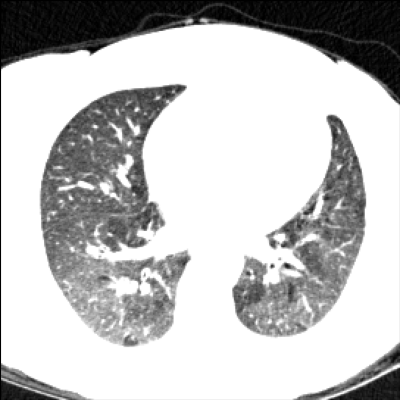

In [123]:
fig, ax = mpl_viz.subplot_grid(1, 1, 4, 4)

ax[0,0].imshow(img0.get_fdata()[c:-c,c:-c,z].T, origin='lower', **img_kws)

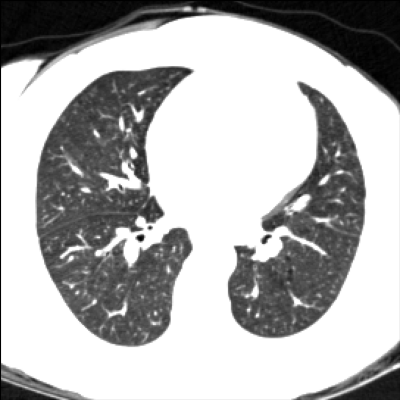

In [124]:
fig, ax = mpl_viz.subplot_grid(1, 1, 4, 4)

ax[0,0].imshow(img1.get_fdata()[c:-c,c:-c,z].T, origin='lower', **img_kws)

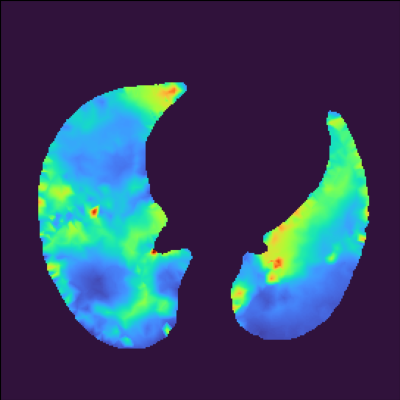

In [130]:
fig, ax = mpl_viz.subplot_grid(1, 1, 4, 4)

ax[0,0].imshow(K_lin[c:-c,c:-c,z].T, origin='lower', cmap='turbo', clim=(0, 20000))

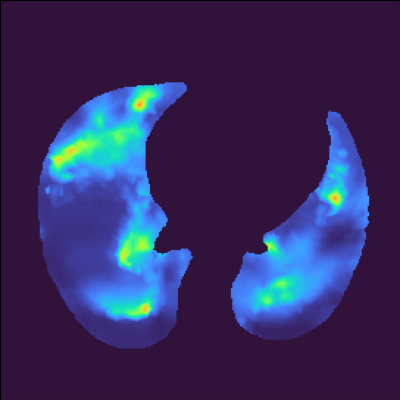

In [132]:
fig, ax = mpl_viz.subplot_grid(1, 1, 4, 4)

ax[0,0].imshow(G_lin[c:-c,c:-c,z].T, origin='lower', cmap='turbo', clim=(0, 10000))

In [133]:
mesh = project.core.fileio.load_meshio('outputs/opt_linear/16514P/meshes/optimized.xdmf')
mesh

Loading outputs/opt_linear/16514P/meshes/optimized.xdmf


<meshio mesh object>
  Number of points: 23583
  Number of cells:
    tetra: 99939
  Point data: medit:ref, image, u_true, mu_pred, lam_pred, rho_pred, u_pred, residual
  Cell data: medit:ref, region, image, u_true, mu_pred, lam_pred, rho_pred, u_pred, residual

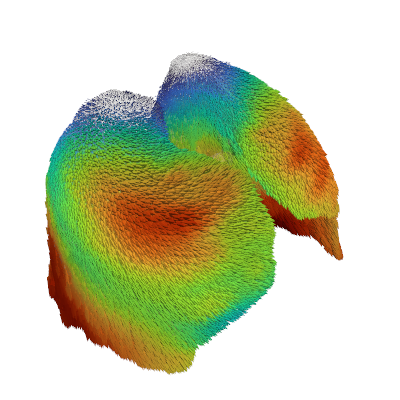

In [161]:
def show_mesh(mesh, key):
    import pyvista as pv
    m = pv.wrap(mesh)
    p = pv.Plotter(window_size=(400,400))
    p.add_mesh(m, show_scalar_bar=False, color='white', opacity=0.2)
    g = m.glyph(scale=key, orient=key, factor=1.0)
    p.add_mesh(g, show_scalar_bar=False, cmap='turbo', clim=(2,24))
    p.camera.zoom(1.25)
    p.show(jupyter_backend='static')

show_mesh(mesh, key='u_true')

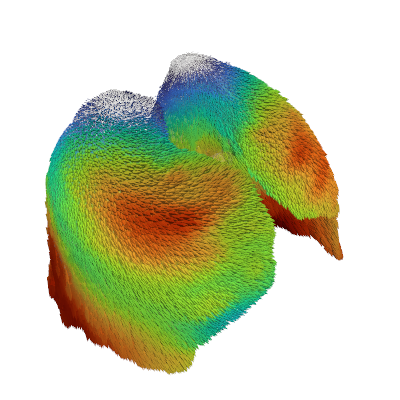

In [162]:
show_mesh(mesh, key='u_pred')

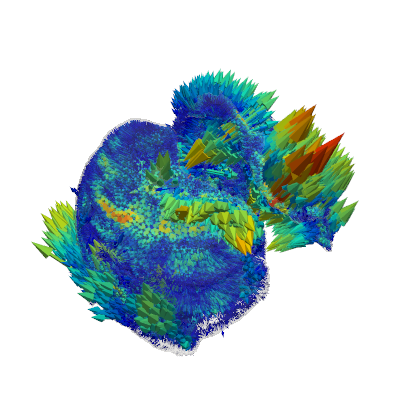

In [142]:
show_mesh(mesh, key='residual')